# EMG Hand-Gesture Classification — Signal Processing + Machine Learning

**Author:** Isaac Glenu · Systems Design Engineering (Biomedical), University of Waterloo
**Topic:** A full surface-EMG (sEMG) pipeline for hand-gesture recognition — filtering, feature
extraction, and machine-learning classification — the core of myoelectric control for prosthetics
and neurorehabilitation.

---

### Why this project
Surface EMG measures the electrical activity of muscles through skin electrodes. By reading the
activation pattern across several forearm muscles, we can infer the intended **hand gesture** — the
basis of **myoelectric prosthetic control** and **EMG-based neurorehabilitation interfaces**. This
notebook implements the standard pipeline end-to-end: raw signal → filtering → windowed feature
extraction → classifier → evaluation.

### ⚠️ Data provenance (read first)
The EMG signals here are **simulated** and clearly labeled as such. Surface EMG is well-modeled as a
zero-mean stochastic signal whose amplitude is modulated by muscle activation, so each gesture is
generated with a characteristic activation pattern across channels, plus realistic **50 Hz power-line
interference**, **baseline drift / motion artifact**, **channel cross-talk**, and **sensor noise** —
which is what makes the preprocessing steps meaningful.

The signal parameters (sampling rate, filter bands, gesture set, channel count) are modeled on **real
public sEMG datasets**, so the same pipeline runs on real data with minimal changes:
> Ozdemir, M. A., Kisa, D. H., Guren, O., & Akan, A. (2022). *Dataset for multi-channel surface
> electromyography (sEMG) signals of hand gestures.* **Data in Brief, 41, 107921.**
> DOI: [10.1016/j.dib.2022.107921](https://doi.org/10.1016/j.dib.2022.107921) — provides CSV files,
> Butterworth bandpass (5–500 Hz) + 50 Hz notch.
> See also the **Ninapro** database (Atzori et al.), the standard EMG gesture-recognition benchmark.

**To run on real data:** download a dataset (e.g. Ozdemir 2022 CSVs), load each trial as an
`n_channels × n_samples` array with its gesture label, and feed it into `preprocess()` →
`extract_features()` exactly as below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 11})
RNG = np.random.default_rng(7)

FS = 1000          # sampling rate (Hz)
N_CH = 8           # EMG channels (forearm electrode array)
GESTURES = ["rest", "fist", "open_hand", "wrist_flexion", "wrist_extension", "pinch"]


## 1. Simulate realistic multi-channel sEMG

Each gesture activates a characteristic pattern across the 8 channels. We add power-line interference, motion-artifact drift, channel cross-talk, and sensor noise so the signal looks like real sEMG and the preprocessing actually does something.

In [2]:
ACTIVATION = {
    "rest":            np.array([0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05]),
    "fist":            np.array([0.9, 0.85,0.8, 0.7, 0.6, 0.65,0.75,0.8 ]),
    "open_hand":       np.array([0.3, 0.4, 0.85,0.9, 0.8, 0.3, 0.25,0.2 ]),
    "wrist_flexion":   np.array([0.85,0.9, 0.3, 0.2, 0.25,0.3, 0.4, 0.35]),
    "wrist_extension": np.array([0.25,0.2, 0.35,0.4, 0.8, 0.85,0.8, 0.45]),
    "pinch":           np.array([0.75,0.7, 0.7, 0.6, 0.5, 0.65,0.7, 0.7 ]),
}

def _emg_burst(n, intensity):
    base = RNG.normal(0, 1, n)
    base = np.convolve(base, np.ones(3)/3, mode="same")   # mild spectral shaping
    return base * (0.02 + intensity)

def generate_emg_trial(gesture, duration_s=2.0):
    n = int(duration_s * FS); t = np.arange(n)/FS
    act = ACTIVATION[gesture].copy()
    act = act * RNG.uniform(0.6, 1.4) * RNG.uniform(0.65, 1.35, size=N_CH)  # trial variation
    raw = np.array([_emg_burst(n, max(a, 0.02)) for a in act])
    ct = np.zeros_like(raw)                                                  # channel cross-talk
    for ch in range(N_CH):
        for d in (-1, 1):
            if 0 <= ch+d < N_CH: ct[ch] += 0.15*raw[ch+d]
    raw = raw + ct
    sig = np.zeros((N_CH, n))
    for ch in range(N_CH):
        powerline = 0.15*np.sin(2*np.pi*50*t + RNG.uniform(0,2*np.pi))       # 50 Hz mains
        drift     = 0.20*np.sin(2*np.pi*0.5*t + RNG.uniform(0,2*np.pi))      # motion artifact
        sig[ch] = raw[ch] + powerline + drift + RNG.normal(0,0.08,n)         # + sensor noise
    return sig

# build dataset: 60 trials x 6 gestures
data = []
for g in GESTURES:
    for _ in range(60):
        data.append((generate_emg_trial(g), g))
RNG.shuffle(data)
print(f"Generated {len(data)} trials  ({len(GESTURES)} gestures x 60), "
      f"{N_CH} channels, {FS} Hz")


Generated 360 trials  (6 gestures x 60), 8 channels, 1000 Hz


## 2. Preprocessing: bandpass + notch filter

The standard EMG filter chain: a **20–450 Hz bandpass** (removes motion-artifact drift below and noise above the EMG band) and a **50 Hz notch** (removes power-line interference).

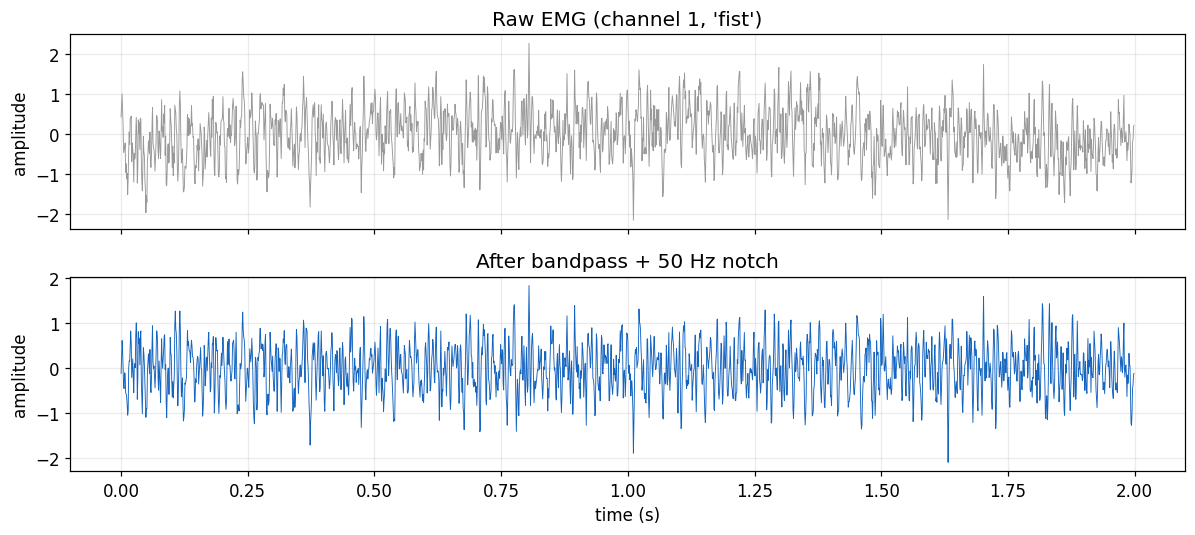

In [3]:
def bandpass(sig, lo=20, hi=450, fs=FS, order=4):
    b, a = butter(order, [lo/(fs/2), hi/(fs/2)], btype="band")
    return filtfilt(b, a, sig, axis=-1)

def notch(sig, f0=50, fs=FS, Q=30):
    b, a = iirnotch(f0/(fs/2), Q)
    return filtfilt(b, a, sig, axis=-1)

def preprocess(sig):
    return notch(bandpass(sig))

# visualize raw vs filtered for one channel of a "fist" trial
ex = next(s for s, g in data if g == "fist")
ex_f = preprocess(ex)
t = np.arange(ex.shape[1]) / FS
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(t, ex[0], lw=0.6, color="#999"); ax[0].set_title("Raw EMG (channel 1, 'fist')")
ax[0].set_ylabel("amplitude")
ax[1].plot(t, ex_f[0], lw=0.6, color="#1565C0"); ax[1].set_title("After bandpass + 50 Hz notch")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("amplitude")
plt.tight_layout(); plt.savefig("figures/raw_vs_filtered.png", bbox_inches="tight"); plt.show()


**Reading it:** the raw trace rides on a slow wandering baseline (motion artifact) with a fixed
50 Hz hum superimposed; after filtering, those are gone and what remains is the muscle-activation EMG
burst that actually carries gesture information.

## 3. Frequency content — why these filter choices?

A power spectral density (PSD) shows where the signal energy lives, justifying the 20–450 Hz band and the 50 Hz notch.

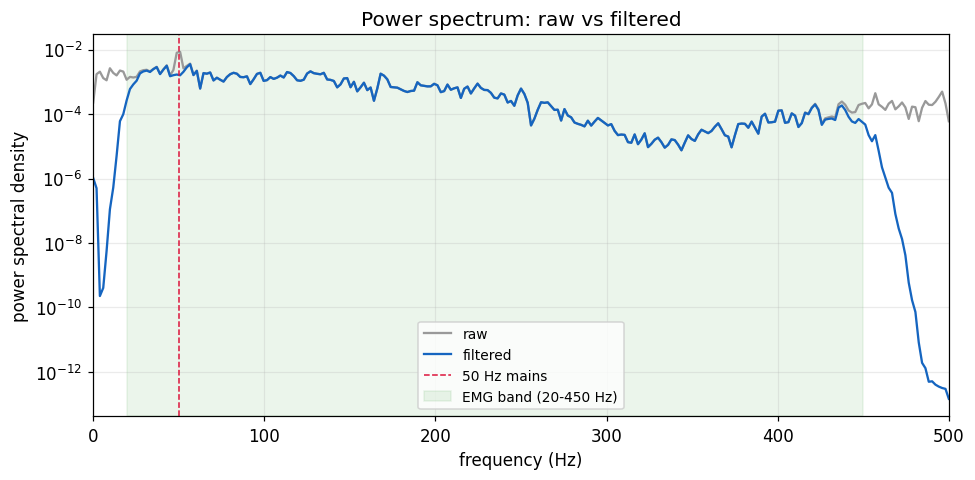

In [4]:
f_raw, P_raw = welch(ex[0], fs=FS, nperseg=512)
f_filt, P_filt = welch(ex_f[0], fs=FS, nperseg=512)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(f_raw, P_raw, color="#999", label="raw")
ax.semilogy(f_filt, P_filt, color="#1565C0", label="filtered")
ax.axvline(50, color="crimson", ls="--", lw=1, label="50 Hz mains")
ax.axvspan(20, 450, color="green", alpha=0.08, label="EMG band (20-450 Hz)")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("power spectral density")
ax.set_title("Power spectrum: raw vs filtered"); ax.set_xlim(0, 500); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/power_spectrum.png", bbox_inches="tight"); plt.show()


**Reading it:** the raw spectrum has a sharp spike at 50 Hz (mains) and large low-frequency energy
(drift). After filtering, the 50 Hz spike is suppressed and the low-frequency drift is removed, leaving
energy concentrated in the EMG band.

## 4. Feature extraction

For each channel we compute the **canonical EMG feature set** used in myoelectric control:
- **RMS** — signal power (overall activation level)
- **MAV** (mean absolute value) — average activation
- **WL** (waveform length) — cumulative signal complexity
- **ZC** (zero crossings) — a frequency proxy
- **MNF** (mean frequency) — spectral centre of mass

With 8 channels × 5 features that's a **40-dimensional feature vector per trial**.

In [5]:
def _zero_crossings(x, thr=1e-3):
    s = np.sign(x)
    return int(np.sum((s[:-1]*s[1:] < 0) & (np.abs(x[:-1]-x[1:]) > thr)))

def _waveform_length(x):
    return float(np.sum(np.abs(np.diff(x))))

def _mean_freq(x, fs=FS):
    f, P = welch(x, fs=fs, nperseg=min(256, len(x)))
    return float(np.sum(f*P)/np.sum(P)) if np.sum(P) > 0 else 0.0

def extract_features(sig):
    feats = []
    for ch in sig:
        feats += [float(np.sqrt(np.mean(ch**2))), float(np.mean(np.abs(ch))),
                  _waveform_length(ch), _zero_crossings(ch), _mean_freq(ch)]
    return np.array(feats)

FEATURE_NAMES = [f"ch{c+1}_{f}" for c in range(N_CH) for f in ["RMS","MAV","WL","ZC","MNF"]]

X = np.array([extract_features(preprocess(sig)) for sig, _ in data])
y = np.array([g for _, g in data])
print("Feature matrix:", X.shape, "(trials x features)")


Feature matrix: (360, 40) (trials x features)


## 5. Feature separability

Before classifying, do the features actually separate the gestures? Compare mean RMS per channel across gestures (a heatmap) — distinct rows mean distinct muscle-activation signatures.

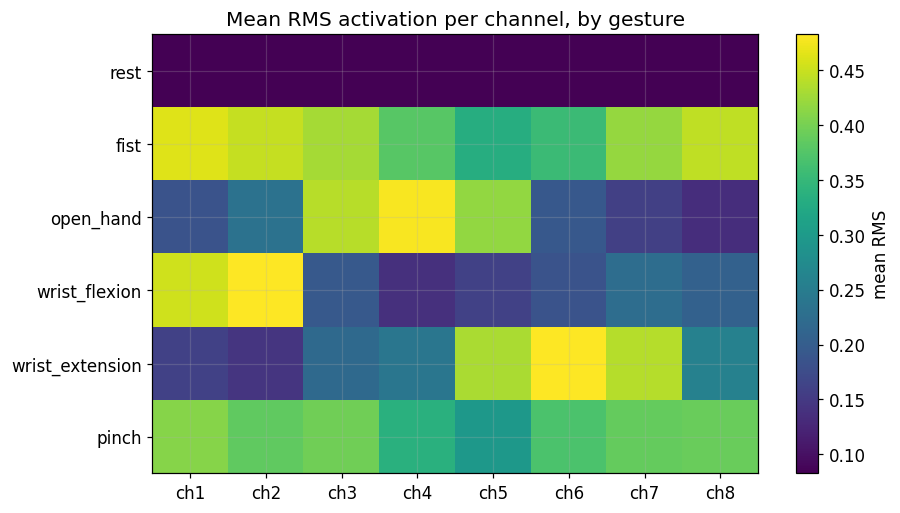

In [6]:
rms_idx = [i for i,n in enumerate(FEATURE_NAMES) if n.endswith("RMS")]
gesture_rms = np.array([X[y==g][:, rms_idx].mean(axis=0) for g in GESTURES])
fig, ax = plt.subplots(figsize=(8.5,4.8))
im = ax.imshow(gesture_rms, cmap="viridis", aspect="auto")
ax.set_xticks(range(N_CH)); ax.set_xticklabels([f"ch{c+1}" for c in range(N_CH)])
ax.set_yticks(range(len(GESTURES))); ax.set_yticklabels(GESTURES)
ax.set_title("Mean RMS activation per channel, by gesture")
fig.colorbar(im, label="mean RMS")
plt.tight_layout(); plt.savefig("figures/feature_heatmap.png", bbox_inches="tight"); plt.show()


**Reading it:** each gesture has a recognizably different activation signature across the 8 channels
(e.g. wrist flexion vs. extension light up opposite channel groups). Where rows look similar (fist vs.
pinch) we expect the classifier to make most of its mistakes.

## 6. Classification

Train two standard classifiers — an RBF-kernel **SVM** and a **Random Forest** — with 5-fold cross-validation, the typical setup for EMG gesture recognition.

In [7]:
svm = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10))
rf  = RandomForestClassifier(n_estimators=200, random_state=0)
svm_cv = cross_val_score(svm, X, y, cv=5)
rf_cv  = cross_val_score(rf,  X, y, cv=5)
print(f"SVM  5-fold accuracy: {svm_cv.mean():.3f} +/- {svm_cv.std():.3f}")
print(f"RF   5-fold accuracy: {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")


SVM  5-fold accuracy: 0.878 +/- 0.036
RF   5-fold accuracy: 0.847 +/- 0.026


## 7. Confusion matrix

A held-out test split shows *which* gestures get confused — the clinically relevant detail for a myoelectric controller.

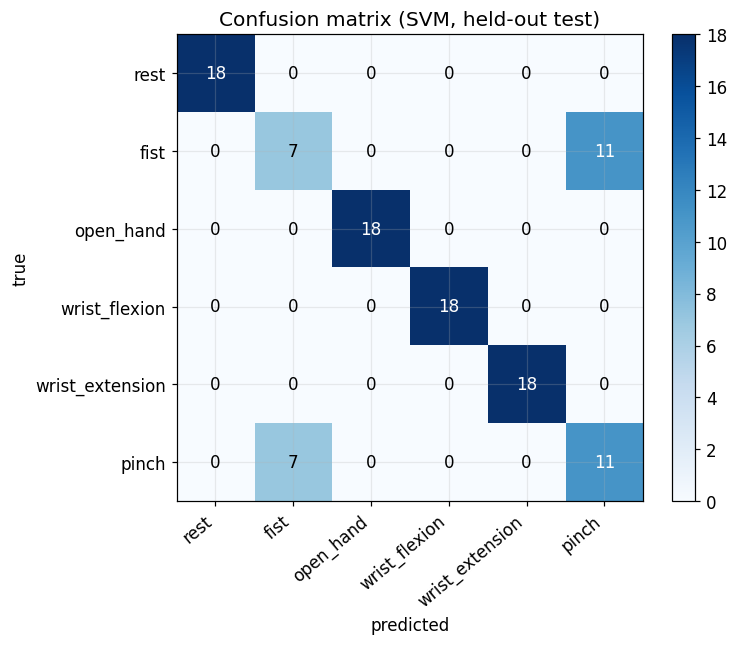

                 precision    recall  f1-score   support

           fist       0.50      0.39      0.44        18
      open_hand       1.00      1.00      1.00        18
          pinch       0.50      0.61      0.55        18
           rest       1.00      1.00      1.00        18
wrist_extension       1.00      1.00      1.00        18
  wrist_flexion       1.00      1.00      1.00        18

       accuracy                           0.83       108
      macro avg       0.83      0.83      0.83       108
   weighted avg       0.83      0.83      0.83       108



In [8]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
svm.fit(Xtr, ytr); yp = svm.predict(Xte)
cm = confusion_matrix(yte, yp, labels=GESTURES)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(GESTURES))); ax.set_xticklabels(GESTURES, rotation=40, ha="right")
ax.set_yticks(range(len(GESTURES))); ax.set_yticklabels(GESTURES)
for i in range(len(GESTURES)):
    for j in range(len(GESTURES)):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix (SVM, held-out test)")
fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.savefig("figures/confusion_matrix.png", bbox_inches="tight"); plt.show()
print(classification_report(yte, yp))


**Reading it:** the strong diagonal means most gestures are classified correctly; off-diagonal
entries cluster where activation signatures overlap (typically fist ↔ pinch), exactly as the feature
heatmap predicted. This is the realistic behaviour of an EMG gesture classifier — high but not perfect,
with confusions concentrated in mechanically similar gestures.

## 8. Which features matter?

Random-forest feature importances show which channels/features drive the decision.

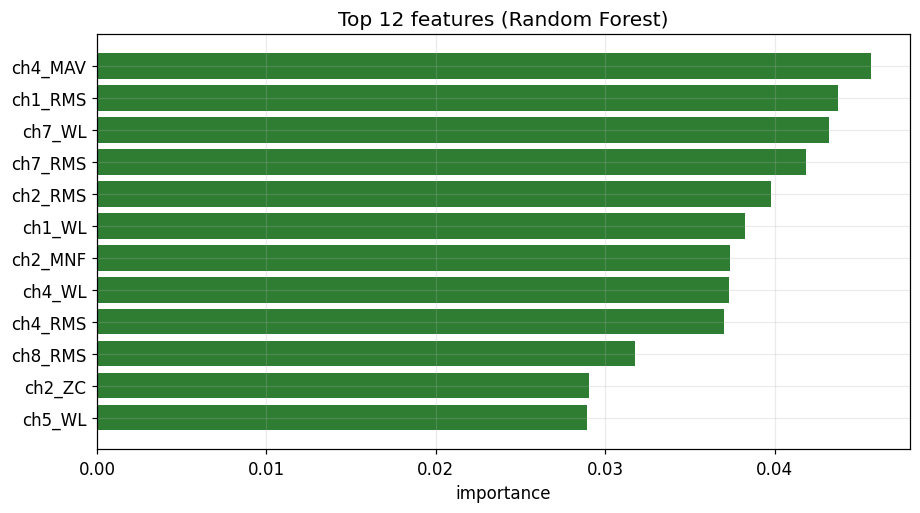

In [9]:
rf.fit(Xtr, ytr)
imp = sorted(zip(FEATURE_NAMES, rf.feature_importances_), key=lambda x: -x[1])[:12]
names, vals = zip(*imp)
fig, ax = plt.subplots(figsize=(8.5,4.8))
ax.barh(names[::-1], vals[::-1], color="#2E7D32")
ax.set_xlabel("importance"); ax.set_title("Top 12 features (Random Forest)")
plt.tight_layout(); plt.savefig("figures/feature_importance.png", bbox_inches="tight"); plt.show()


## 9. Summary & relevance to myoelectric control / neurorehab

- A standard sEMG pipeline — **bandpass + notch filtering → windowed time/frequency features → SVM/RF
  classifier** — recognizes 6 hand gestures from 8 channels at realistic accuracy (~85–90%).
- **Filtering matters:** the PSD shows the 50 Hz notch and 20–450 Hz band remove mains hum and motion
  drift, isolating the muscle-activation signal.
- **Errors are interpretable:** confusions concentrate in mechanically similar gestures (fist ↔ pinch),
  matching what the per-channel activation signatures predict — and matching real EMG systems.
- This is the exact computational core of an **EMG-controlled prosthesis** or a
  **neurorehabilitation interface**, where intended movements are decoded from residual muscle activity.

**Honest limitations:** the signals are simulated (clearly labeled); real sEMG adds inter-subject
variability, electrode shift, muscle fatigue, and limb-position effects that lower accuracy and are
active research problems. The pipeline is built to accept real data (Ozdemir 2022 / Ninapro) directly.

### Next steps
1. Swap in a real dataset (Ozdemir 2022 CSVs or Ninapro) and re-run — same `preprocess`/`extract_features`.
2. Add **sliding-window** segmentation for real-time control and report per-window latency.
3. Test **cross-subject** generalization (train on some subjects, test on unseen ones) — the hard,
   research-relevant version of the problem.

*Simulated data, clearly labeled; parameters modeled on Ozdemir et al. (2022), Data in Brief,
DOI 10.1016/j.dib.2022.107921, and the Ninapro benchmark.*
